In [1]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [2]:
#1.Scalars, vectors, matrices & tensors
# 1A. THE FOUR CONTAINERS
scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')
# 1B. TENSOR OPERATIONS: add, transpose, reshape
A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)
print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)
A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [3]:
print("excercise-1")
T = np.arange(12).reshape(3, 4)
print('T:\n', T)
# 1. ndim and shape
print('ndim:', T.ndim)
print('shape:', T.shape)
# 2. T + T
print('T + T:\n', T + T)
# 3. Transpose and reshape to (2, 6)
print('Transpose shape:', T.T.shape)
print('T reshaped to (2, 6):\n', T.reshape(2, 6))


excercise-1
T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
ndim: 2
shape: (3, 4)
T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
Transpose shape: (4, 3)
T reshaped to (2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


In [4]:
#2.Dot & cross products, and norms
#2A. DOT & CROSS PRODUCTS
a = np.array([1, 2, 3])
b = np.array([4, 0, 1])
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7
print('a x b  (cross) :', np.cross(a, b))
#2B. NORMS (vector length) + COSINE SIMILARITY
print('L2 norm  ||a||_2 :', la.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', la.norm(a, 1))      # sum of absolute values
print('Linf norm        :', la.norm(a, np.inf)) # max absolute value
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))
print('cosine(a, b)     :', round(cosine(a, b), 3))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]
L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [7]:
print("excercise-2")
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]
for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    print(f'Pair {i}:')
    print('  L1 norm:', la.norm(u, 1))
    print('  L2 norm:', la.norm(u))
    # 2. Cosine similarity of u and v
    print('  Cosine similarity:', round(cosine(u, v), 3))
    print()
# 3. Most similar pair = Pair 1


excercise-2
Pair 1:
  L1 norm: 2.0
  L2 norm: 1.4142135623730951
  Cosine similarity: 1.0

Pair 2:
  L1 norm: 6.0
  L2 norm: 3.7416573867739413
  Cosine similarity: 0.714

Pair 3:
  L1 norm: 2.0
  L2 norm: 2.0
  Cosine similarity: 0.0



In [8]:
#3.Matrix operations & special matrices
#3A. CORE MATRIX OPERATIONS
A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])
print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))
#3B. SPECIAL MATRICES: identity, symmetric, orthogonal
I = np.eye(2)
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))
print('A symmetric?', np.allclose(A, A.T))
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0
Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [9]:
print("excerice-3")
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])
# 1. inverse and trace of M
print('inverse(M):\n', la.inv(M))
print('trace(M):', np.trace(M))
# 2. M @ inv(M) == I ?
I = np.eye(2)
print('M @ inv(M) == I ?', np.allclose(M @ la.inv(M), I))
# 3. Is M symmetric? Is P orthogonal?
print('M symmetric?', np.allclose(M, M.T))
print('P orthogonal?', np.allclose(P.T @ P, I))

excerice-3
inverse(M):
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
trace(M): 7.0
M @ inv(M) == I ? True
M symmetric? True
P orthogonal? True


Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


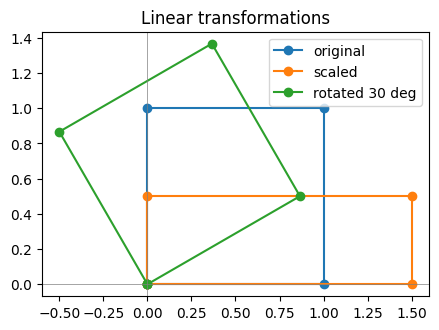

In [10]:
#4.Transformations: rotation & scaling
#4A. BUILD TRANSFORMATION MATRICES
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])
scaled  = S @ square
rotated = R @ square
print('Rotated corners:\n', rotated)
#4B. PLOT ORIGINAL vs TRANSFORMED
def close_loop(pts):
    return np.hstack([pts, pts[:, :1]])
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

excercise-4


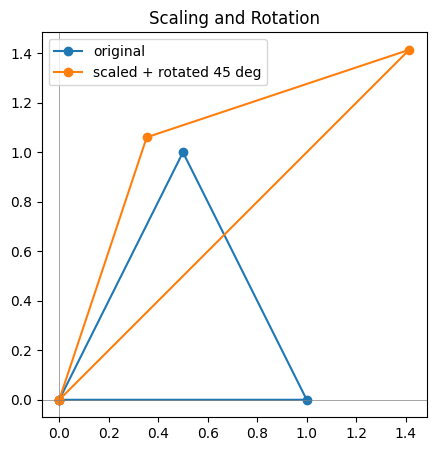

In [11]:
print("excercise-4")
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])
# 1. Scaling matrix (x*2, y*0.5)
S = np.array([[2.0, 0.0],
              [0.0, 0.5]])
# 2. Rotation matrix (45 degrees)
t = np.radians(45)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])
# 3. Apply both transformations
scaled = S @ tri
transformed = R @ scaled
# Plot original vs transformed
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(tri), marker='o', label='original')
ax.plot(*close_loop(transformed), marker='o', label='scaled + rotated 45 deg')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')
ax.legend()
ax.set_title('Scaling and Rotation')
plt.show()

In [12]:
#5. Eigenvalues & eigenvectors
#5A. COMPUTE EIGENVALUES & EIGENVECTORS
A = np.array([[2., 0.],
              [0., 3.]])
vals, vecs = la.eig(A)
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)
#5B. VERIFY  A v = lambda v
for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))


Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]
lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [13]:
print("excercise-5")
C = np.array([[4., 1.],
              [2., 3.]])
# 1. Eigenvalues and eigenvectors
vals, vecs = la.eig(C)
# 2. Print eigenvalues
print('Eigenvalues:', vals)
print('Eigenvectors (columns):\n', vecs)
# 3. Verify C @ v = lambda * v for the first eigenvector
v = vecs[:, 0]
lhs = C @ v
rhs = vals[0] * v
print('C @ v == lambda * v ?', np.allclose(lhs, rhs))

excercise-5
Eigenvalues: [5. 2.]
Eigenvectors (columns):
 [[ 0.707 -0.447]
 [ 0.707  0.894]]
C @ v == lambda * v ? True


In [14]:
#6. Rank, solving systems & cosine similarity
#6A. SOLVE A 3x3 SYSTEM  A x = b
A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])
x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')
# 6B. RANK TELLS YOU SOLVABILITY
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists
Rank of D: 2 -> < 3, so rows are dependent


In [15]:
print("excercise-6")
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])
cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])
# 1. Solve A2 x = b2
x = la.solve(A2, b2)
print('Solution x:', x)
# 2. Rank of A2
print('Rank of A2:', la.matrix_rank(A2))
# 3. Cosine similarity
print('cosine(cat, dog):', round(cosine(cat, dog), 3))
print('cosine(cat, car):', round(cosine(cat, car), 3))
# Dog is more similar to cat

excercise-6
Solution x: [1. 2.]
Rank of A2: 2
cosine(cat, dog): 0.995
cosine(cat, car): 0.293
